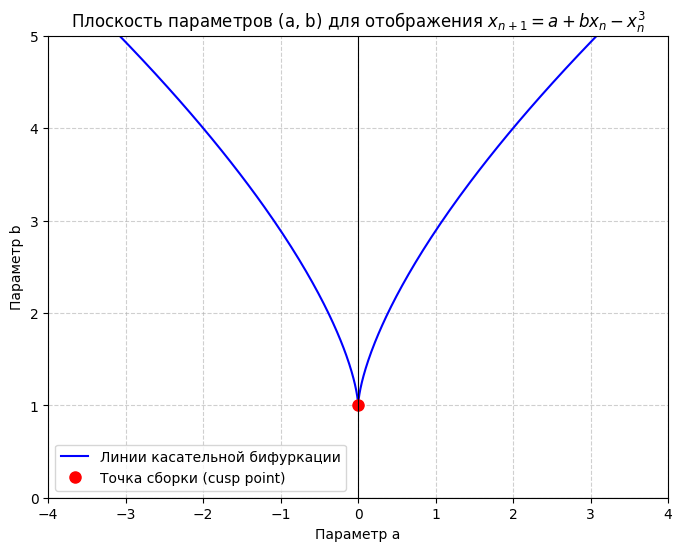

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x_vals = np.linspace(-1.5, 1.5, 400)

# a(x) = -2*x^3
# b(x) = 1 + 3*x^2
a_bif = -2 * x_vals**3
b_bif = 1 + 3 * x_vals**2

a_cusp = 0
b_cusp = 1

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(a_bif, b_bif, 'b-', label='Линии касательной бифуркации')

ax.plot(a_cusp, b_cusp, 'ro', markersize=8, label='Точка сборки (cusp point)')

ax.set_title('Плоскость параметров (a, b) для отображения $x_{n+1} = a + b x_n - x_n^3$')
ax.set_xlabel('Параметр a')
ax.set_ylabel('Параметр b')

ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)

ax.set_xlim(-4, 4)
ax.set_ylim(0, 5)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.show()

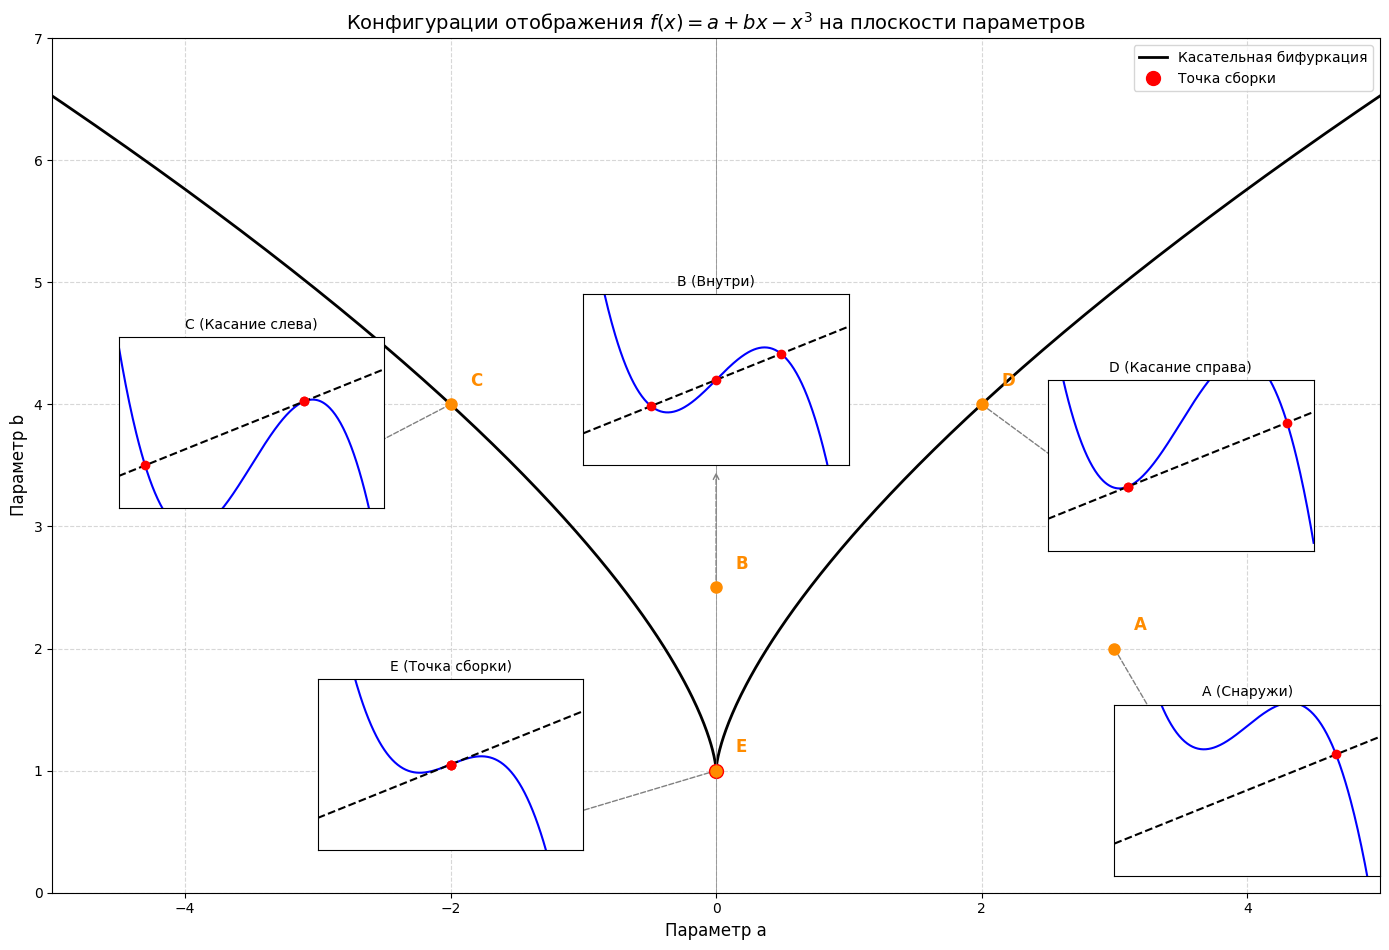

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch

x_vals_tangent = np.linspace(-1.5, 1.5, 400)
a_tangent = -2 * x_vals_tangent**3
b_tangent = 1 + 3 * x_vals_tangent**2
a_cusp, b_cusp = 0, 1

fig = plt.figure(figsize=(14, 10))
#GridSpec для гибкого расположения
gs = fig.add_gridspec(3, 3)
ax_main = fig.add_subplot(gs[0:3, 0:3])

def plot_inset_graph(ax, a, b, title):
    x = np.linspace(-2.5, 2.5, 300)
    y_func = a + b * x - x**3

    ax.plot(x, y_func, 'b-', label='$f(x)$')
    ax.plot(x, x, 'k--', label='$y=x$')

    #неподвижные точки (корни уравнения f(x)-x=0): -x^3 + (b-1)x + a = 0
    coeffs = [-1, 0, b - 1, a]
    fixed_points = np.roots(coeffs)
    real_fps = fixed_points[np.isreal(fixed_points)].real

    ax.plot(real_fps, real_fps, 'ro', markersize=6)

    ax.set_title(title, fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylim(-4, 4)
    ax.set_xlim(-2.5, 2.5)

points_to_show = {
    'A (Снаружи)': {'coords': (3, 2), 'pos': [0.8, 0.02, 0.2, 0.2]},
    'B (Внутри)': {'coords': (0, 2.5), 'pos': [0.4, 0.5, 0.2, 0.2]},
    'C (Касание слева)': {'coords': (-2, 4), 'pos': [0.05, 0.45, 0.2, 0.2]},
    'D (Касание справа)': {'coords': (2, 4), 'pos': [0.75, 0.4, 0.2, 0.2]},
    'E (Точка сборки)': {'coords': (0, 1), 'pos': [0.2, 0.05, 0.2, 0.2]}
}

ax_main.plot(a_tangent, b_tangent, 'k-', linewidth=2, label='Касательная бифуркация')
ax_main.plot(a_cusp, b_cusp, 'ro', markersize=10, label='Точка сборки')
ax_main.set_title('Конфигурации отображения $f(x)=a+bx-x^3$ на плоскости параметров', fontsize=14)
ax_main.set_xlabel('Параметр a', fontsize=12)
ax_main.set_ylabel('Параметр b', fontsize=12)
ax_main.axhline(0, color='gray', lw=0.5)
ax_main.axvline(0, color='gray', lw=0.5)
ax_main.set_xlim(-5, 5)
ax_main.set_ylim(0, 7)
ax_main.grid(True, linestyle='--', alpha=0.5)

for name, data in points_to_show.items():
    a, b = data['coords']
    pos = data['pos']

    ax_main.plot(a, b, 'o', color='darkorange', markersize=8)
    ax_main.text(a + 0.15, b + 0.15, name.split(' ')[0], fontsize=12, color='darkorange', weight='bold')

    ax_inset = ax_main.inset_axes(pos)
    plot_inset_graph(ax_inset, a, b, name)

    con = ConnectionPatch(xyA=(a, b), xyB=(0.5, 0), coordsA='data', coordsB='axes fraction',
                          axesA=ax_main, axesB=ax_inset, arrowstyle="->",
                          shrinkB=5, color='gray', linestyle='dashed')
    ax_main.add_artist(con)


ax_main.legend()
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

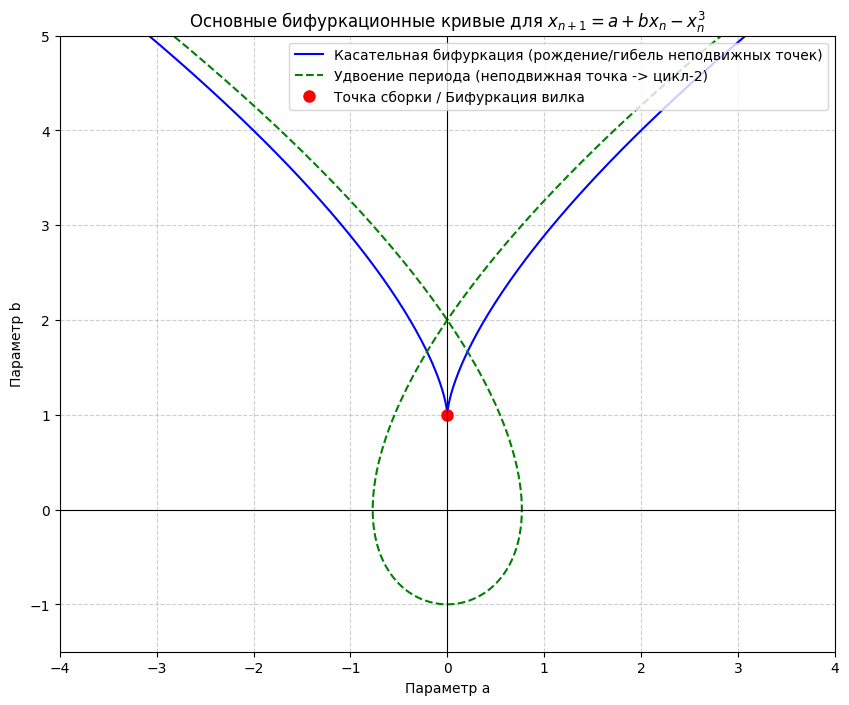

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x_vals_tangent = np.linspace(-1.5, 1.5, 400)
a_tangent = -2 * x_vals_tangent**3
b_tangent = 1 + 3 * x_vals_tangent**2

x_vals_pd = np.linspace(-2, 2, 400)
a_pd = 2*x_vals_pd - 2*x_vals_pd**3
b_pd = 3*x_vals_pd**2 - 1

a_cusp = 0
b_cusp = 1

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(a_tangent, b_tangent, 'b-', label='Касательная бифуркация (рождение/гибель неподвижных точек)')
ax.plot(a_pd, b_pd, 'g--', label='Удвоение периода (неподвижная точка -> цикл-2)')
ax.plot(a_cusp, b_cusp, 'ro', markersize=8, label='Точка сборки / Бифуркация вилка')

ax.set_title('Основные бифуркационные кривые для $x_{n+1} = a + b x_n - x_n^3$')
ax.set_xlabel('Параметр a')
ax.set_ylabel('Параметр b')

ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(-4, 4)
ax.set_ylim(-1.5, 5)

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.show()

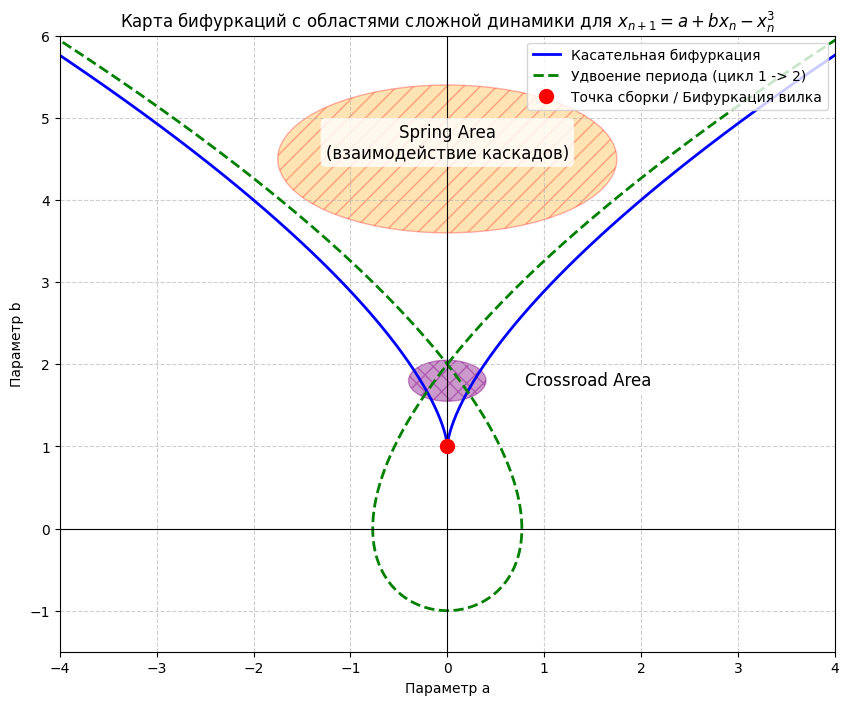

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Polygon

x_vals_tangent = np.linspace(-1.5, 1.5, 400)
a_tangent = -2 * x_vals_tangent**3
b_tangent = 1 + 3 * x_vals_tangent**2

x_vals_pd = np.linspace(-2, 2, 400)
a_pd = 2*x_vals_pd - 2*x_vals_pd**3
b_pd = 3*x_vals_pd**2 - 1

a_cusp, b_cusp = 0, 1

fig, ax = plt.subplots(figsize=(10, 8))

# spring area: большая область выше, где взаимодействуют два каскада
spring_area = Ellipse(xy=(0, 4.5), width=3.5, height=1.8, angle=0,
                        facecolor='orange', alpha=0.3, hatch='//', edgecolor='red')
ax.add_patch(spring_area)
ax.text(0, 4.7, 'Spring Area\n(взаимодействие каскадов)', ha='center', va='center', fontsize=12, color='black',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=0.8))


# crossroad area: маленькая область около точки сборки
crossroad_area = Ellipse(xy=(0, 1.8), width=0.8, height=0.5, angle=0,
                         facecolor='purple', alpha=0.4, hatch='xx', edgecolor='purple')
ax.add_patch(crossroad_area)
ax.text(0.8, 1.8, 'Crossroad Area', ha='left', va='center', fontsize=12, color='black',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=0.8))


ax.plot(a_tangent, b_tangent, 'b-', linewidth=2, label='Касательная бифуркация')
ax.plot(a_pd, b_pd, 'g--', linewidth=2, label='Удвоение периода (цикл 1 -> 2)')
ax.plot(a_cusp, b_cusp, 'ro', markersize=10, zorder=10, label='Точка сборки / Бифуркация вилка')

ax.set_title('Карта бифуркаций с областями сложной динамики для $x_{n+1} = a + b x_n - x_n^3$')
ax.set_xlabel('Параметр a')
ax.set_ylabel('Параметр b')

ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)

ax.set_xlim(-4, 4)
ax.set_ylim(-1.5, 6)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right')

plt.show()

/tmp/ipython-input-4227141128.py:27: RuntimeWarning: overflow encountered in power
  X = A + B * X - X**3
/tmp/ipython-input-4227141128.py:27: RuntimeWarning: overflow encountered in multiply
  X = A + B * X - X**3
/tmp/ipython-input-4227141128.py:27: RuntimeWarning: invalid value encountered in subtract
  X = A + B * X - X**3
/tmp/ipython-input-4227141128.py:32: RuntimeWarning: overflow encountered in square
  derivative = B - 3 * X**2
/tmp/ipython-input-4227141128.py:30: RuntimeWarning: overflow encountered in power
  X = A + B * X - X**3
/tmp/ipython-input-4227141128.py:30: RuntimeWarning: invalid value encountered in subtract
  X = A + B * X - X**3


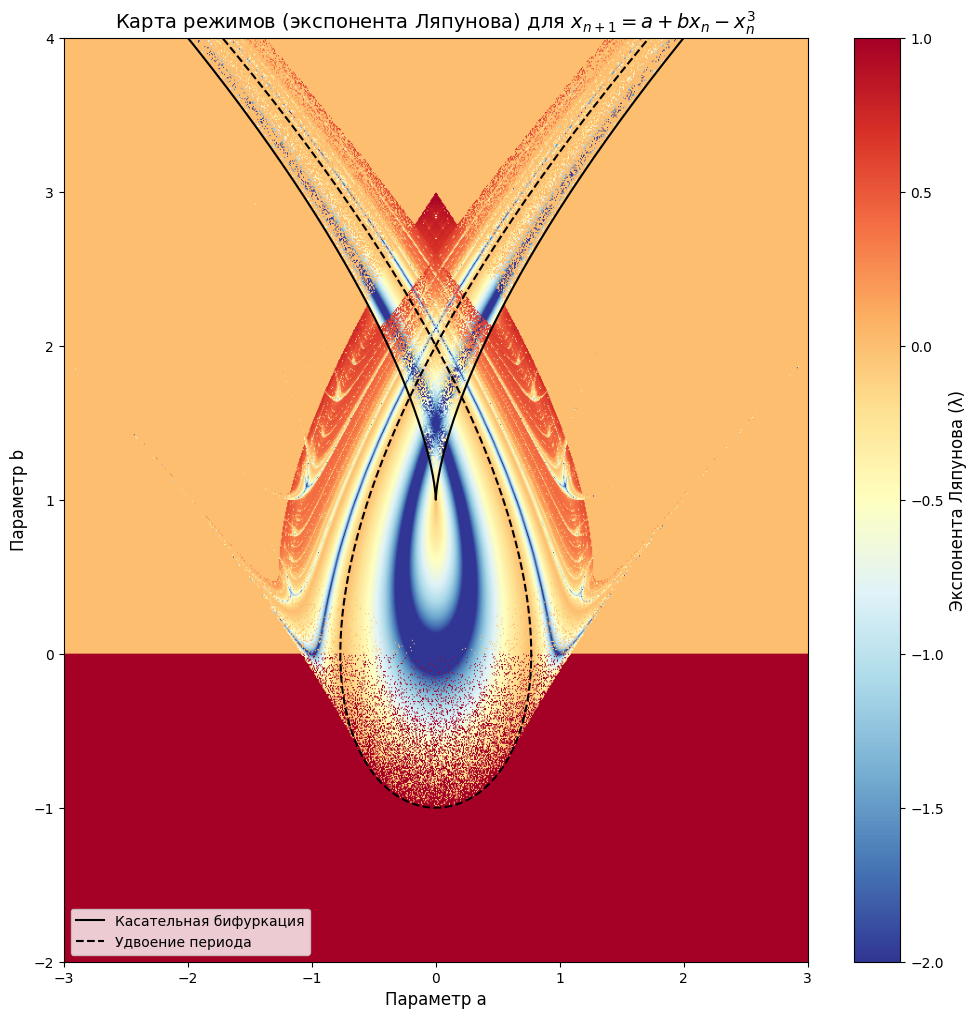

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# 800x800
n_a = 800
n_b = 800

a_min, a_max = -3.0, 3.0
b_min, b_max = -2, 4.0

n_transient = 500  # прогрев
n_lyapunov = 1000  # для вычисления ляпуновской экспоненты

a_vals = np.linspace(a_min, a_max, n_a)
b_vals = np.linspace(b_min, b_max, n_b)
A, B = np.meshgrid(a_vals, b_vals) # 2D сетки

# X == текущее значение x для каждой точки (a,b)
X = np.random.uniform(-1, 1, A.shape)
lyapunov_sum = np.zeros(A.shape) # копим сумму для ляп эксп

start_time = time.time()

# прогрев
for i in range(n_transient):
    X = A + B * X - X**3

for i in range(n_lyapunov):
    X = A + B * X - X**3
    # f'(x) = b - 3x^2 для каждой точки
    derivative = B - 3 * X**2
    # + к сумме log(|f'(x)|), != log(0)
    # np.seterr(divide='ignore') отключает предупреждения о делении на ноль
    with np.errstate(divide='ignore'):
        lyapunov_sum += np.log(np.abs(derivative))

# усредняем, получаем финальную эксп
# -inf == log(0) ==>  большое отрицательное число для корректного отображения
lyapunov_exp = np.nan_to_num(lyapunov_sum / n_lyapunov, neginf=-5)

end_time = time.time()

fig, ax = plt.subplots(figsize=(12, 12))

# cmap='RdYlBu_r' - хорошая палитра: красный > 0 (хаос), желтый = 0, синий < 0 (порядок)
im = ax.imshow(lyapunov_exp, extent=[a_min, a_max, b_min, b_max], origin='lower',
               cmap='RdYlBu_r', aspect='auto', vmin=-2, vmax=1)

# касательная бифуркация
x_t = np.linspace(-1.5, 1.5, 400)
a_t = -2 * x_t**3
b_t = 1 + 3 * x_t**2
ax.plot(a_t, b_t, 'k-', linewidth=1.5, label='Касательная бифуркация')

# удвоение периода
x_p = np.linspace(-2, 2, 400)
a_p = 2*x_p - 2*x_p**3
b_p = 3*x_p**2 - 1
ax.plot(a_p, b_p, 'k--', linewidth=1.5, label='Удвоение периода')


ax.set_title(f'Карта режимов (экспонента Ляпунова) для $x_{{n+1}} = a + b x_n - x_n^3$', fontsize=14)
ax.set_xlabel('Параметр a', fontsize=12)
ax.set_ylabel('Параметр b', fontsize=12)
ax.set_xlim(a_min, a_max)
ax.set_ylim(b_min, b_max)
ax.legend()

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Экспонента Ляпунова (λ)', fontsize=12)
plt.show()

Начинаю вычисления...


/tmp/ipython-input-980602194.py:24: RuntimeWarning: overflow encountered in power
  X = A + B * X - X**3
/tmp/ipython-input-980602194.py:24: RuntimeWarning: overflow encountered in multiply
  X = A + B * X - X**3
/tmp/ipython-input-980602194.py:24: RuntimeWarning: invalid value encountered in subtract
  X = A + B * X - X**3
/tmp/ipython-input-980602194.py:27: RuntimeWarning: overflow encountered in square
  derivative = B - 3 * X**2
/tmp/ipython-input-980602194.py:26: RuntimeWarning: overflow encountered in power
  X = A + B * X - X**3
/tmp/ipython-input-980602194.py:26: RuntimeWarning: invalid value encountered in subtract
  X = A + B * X - X**3


Вычисления завершены за 40.18 секунд.


/usr/local/lib/python3.12/dist-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


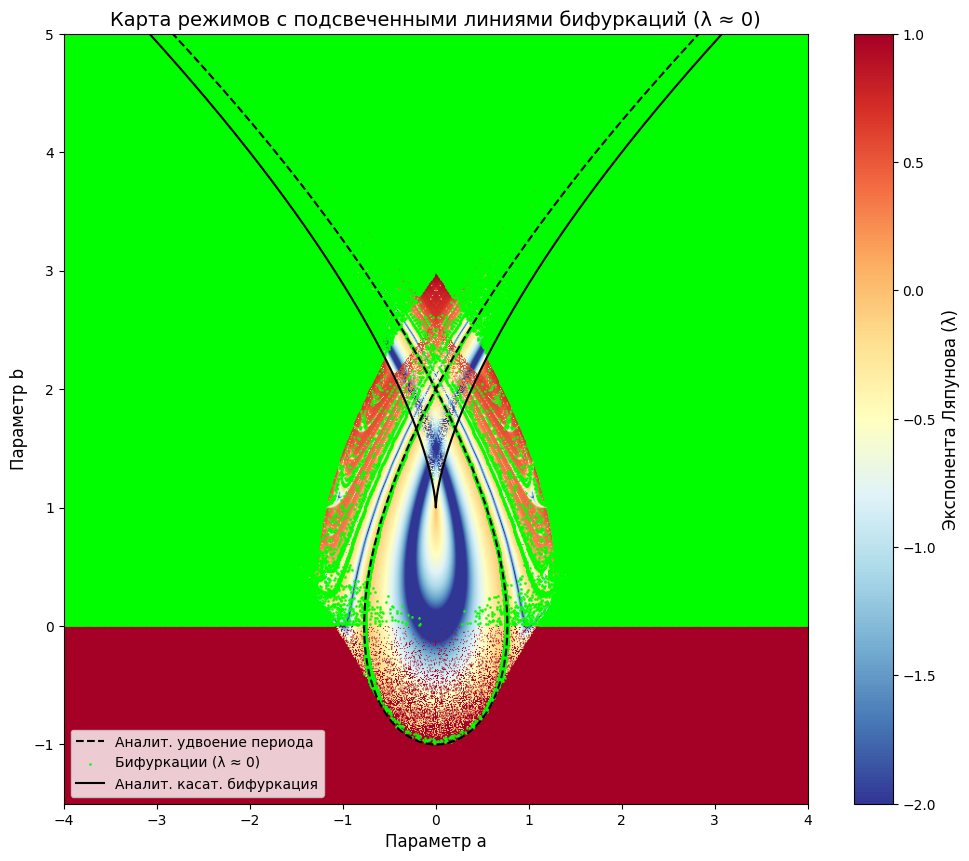

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

n_a = 800
n_b = 800
a_min, a_max = -4.0, 4.0
b_min, b_max = -1.5, 5.0
n_transient = 500
n_lyapunov = 1000

a_vals = np.linspace(a_min, a_max, n_a)
b_vals = np.linspace(b_min, b_max, n_b)
A, B = np.meshgrid(a_vals, b_vals)
X = np.random.uniform(-1, 1, A.shape)
lyapunov_sum = np.zeros(A.shape)

start_time = time.time()
for i in range(n_transient):
    X = A + B * X - X**3
for i in range(n_lyapunov):
    X = A + B * X - X**3
    derivative = B - 3 * X**2
    with np.errstate(divide='ignore'):
        lyapunov_sum += np.log(np.abs(derivative))
lyapunov_exp = np.nan_to_num(lyapunov_sum / n_lyapunov, neginf=-5)
end_time = time.time()

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(lyapunov_exp, extent=[a_min, a_max, b_min, b_max], origin='lower',
               cmap='RdYlBu_r', aspect='auto', vmin=-2, vmax=1)

bif_threshold = 0.05

bifurcation_indices = np.where(np.abs(lyapunov_exp) < bif_threshold)

a_bif_coords = a_vals[bifurcation_indices[1]]
b_bif_coords = b_vals[bifurcation_indices[0]]

ax.scatter(a_bif_coords, b_bif_coords, color='lime', s=1, alpha=0.8, label='Бифуркации (λ ≈ 0)')



x_t = np.linspace(-1.5, 1.5, 400)
a_t = -2 * x_t**3
b_t = 1 + 3 * x_t**2
ax.plot(a_t, b_t, 'k-', linewidth=1.5, label='Аналит. касат. бифуркация')

x_p = np.linspace(-2, 2, 400)
a_p = 2*x_p - 2*x_p**3
b_p = 3*x_p**2 - 1
ax.plot(a_p, b_p, 'k--', linewidth=1.5, label='Аналит. удвоение периода')

ax.set_title(f'Карта режимов с подсвеченными линиями бифуркаций (λ ≈ 0)', fontsize=14)
ax.set_xlabel('Параметр a', fontsize=12)
ax.set_ylabel('Параметр b', fontsize=12)
ax.set_xlim(a_min, a_max)
ax.set_ylim(b_min, b_max)

handles, labels = ax.get_legend_handles_labels()
order = [2, 0, 1] # порядок: сначала точки, потом линии
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order])


cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Экспонента Ляпунова (λ)', fontsize=12)

plt.show()